### 0. Banco de dados

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset from UCI Machine Learning Repository
energy_efficiency = fetch_ucirepo(id=242) 
  
# data (as pandas dataframes) 
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets 

### 1. Análise Exploratória

#### 1.1 Estrutura geral do dataset e dicionário de dados

O conjunto de dados *Energy Efficiency* foi obtido do repositório UCI Machine Learning Repository. Ele contém simulações de 768 edifícios, variando em características como área superficial, altura, orientação e áreas envidraçadas. O objetivo do estudo foi avaliar as cargas térmicas de aquecimento e resfriamento em função dessas características, visando otimizar a eficiência energética das construções.

**Fonte:** [UCI Energy Efficiency Dataset](https://archive.ics.uci.edu/dataset/242/energy+efficiency)  
**Criadores:** Athanasios Tsanas & Angeliki Xifara (2012).  
**Artigo associado:** [Accurate quantitative estimation of energy performance of residential buildings using statistical machine learning tools](https://www.semanticscholar.org/paper/Accurate-quantitative-estimation-of-energy-of-using-Tsanas-Xifara/719e65379c5959141180a45f540f707d583b8ce2).

**Número de instâncias:** 768  
**Número de atributos (features):** 8  
**Número de variáveis-alvo:** 2 (Heating Load e Cooling Load)

**Dicionário de dados:**

| Variável | Descrição | Tipo |
|----------|-----------|------|
| X1 - Relative Compactness | Compacidade relativa | float64 |
| X2 - Surface Area | Área superficial | float64 |
| X3 - Wall Area | Área das paredes | float64 |
| X4 - Roof Area | Área do telhado | float64 |
| X5 - Overall Height | Altura total | float64 |
| X6 - Orientation | Orientação (valores 2, 3, 4, 5) | int64 |
| X7 - Glazing Area | Área envidraçada | float64 |
| X8 - Glazing Area Distribution | Distribuição da área envidraçada (categorias de 0 a 5) | int64 |

**Variáveis-alvo:**
- Y1 - Heating Load (Carga térmica de aquecimento) [Real].
- Y2 - Cooling Load (Carga térmica de resfriamento) [Real].

*Nota:* Não há valores ausentes neste conjunto de dados.


In [2]:
print("Dimensões do conjunto de dados (feature):", X.shape)
X.head()

Dimensões do conjunto de dados (feature): (768, 8)


,X1,X2,X3,X4,X5,X6,X7,X8
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0


In [3]:
print("Dimensões do conjunto de dados (target):", y.shape)
y.head()

Dimensões do conjunto de dados (target): (768, 2)


,Y1,Y2
0,15.55,21.33
1,15.55,21.33
2,15.55,21.33
3,15.55,21.33
4,20.84,28.28


#### 1.2 Estatísticas descritivas

Nesta seção, são apresentadas as estatísticas descritivas das variáveis preditoras e das variáveis-alvo do conjunto de dados. Essas estatísticas incluem medidas como média, desvio padrão, valores mínimos, máximos e os percentis (25%, 50% e 75%).

In [4]:
print("Estatísticas descritivas das variáveis preditoras:")
desc_X = X.describe().T
desc_X

Estatísticas descritivas das variáveis preditoras:


,count,mean,std,min,25%,50%,75%,max
X1,768.0,0.764167,0.105777,0.62,0.6825,0.75,0.830,0.98
X2,768.0,671.708333,88.086116,514.50,606.3750,673.75,741.125,808.50
X3,768.0,318.500000,43.626481,245.00,294.0000,318.50,343.000,416.50
X4,768.0,176.604167,45.165950,110.25,140.8750,183.75,220.500,220.50
X5,768.0,5.250000,1.751140,3.50,3.5000,5.25,7.000,7.00
X6,768.0,3.500000,1.118763,2.00,2.7500,3.50,4.250,5.00
X7,768.0,0.234375,0.133221,0.00,0.1000,0.25,0.400,0.40
X8,768.0,2.812500,1.550960,0.00,1.7500,3.00,4.000,5.00


In [5]:
print("Estatísticas descritivas das variáveis resposta:")
desc_y = y.describe().T
desc_y

Estatísticas descritivas das variáveis resposta:


,count,mean,std,min,25%,50%,75%,max
Y1,768.0,22.307201,10.090196,6.01,12.9925,18.95,31.6675,43.10
Y2,768.0,24.587760,9.513306,10.90,15.6200,22.08,33.1325,48.03


#### 1.3 Distribuição das variáveis

Nesta etapa, são analisadas as distribuições de todas as variáveis do conjunto de dados por meio de histogramas. Esses gráficos permitem identificar padrões, assimetrias, possíveis outliers e a dispersão dos valores.

In [6]:
for col in X.columns:
    print(f'{col}: {X[col].nunique()} valores únicos')

X1: 12 valores únicos
X2: 12 valores únicos
X3: 7 valores únicos
X4: 4 valores únicos
X5: 2 valores únicos
X6: 4 valores únicos
X7: 4 valores únicos
X8: 6 valores únicos


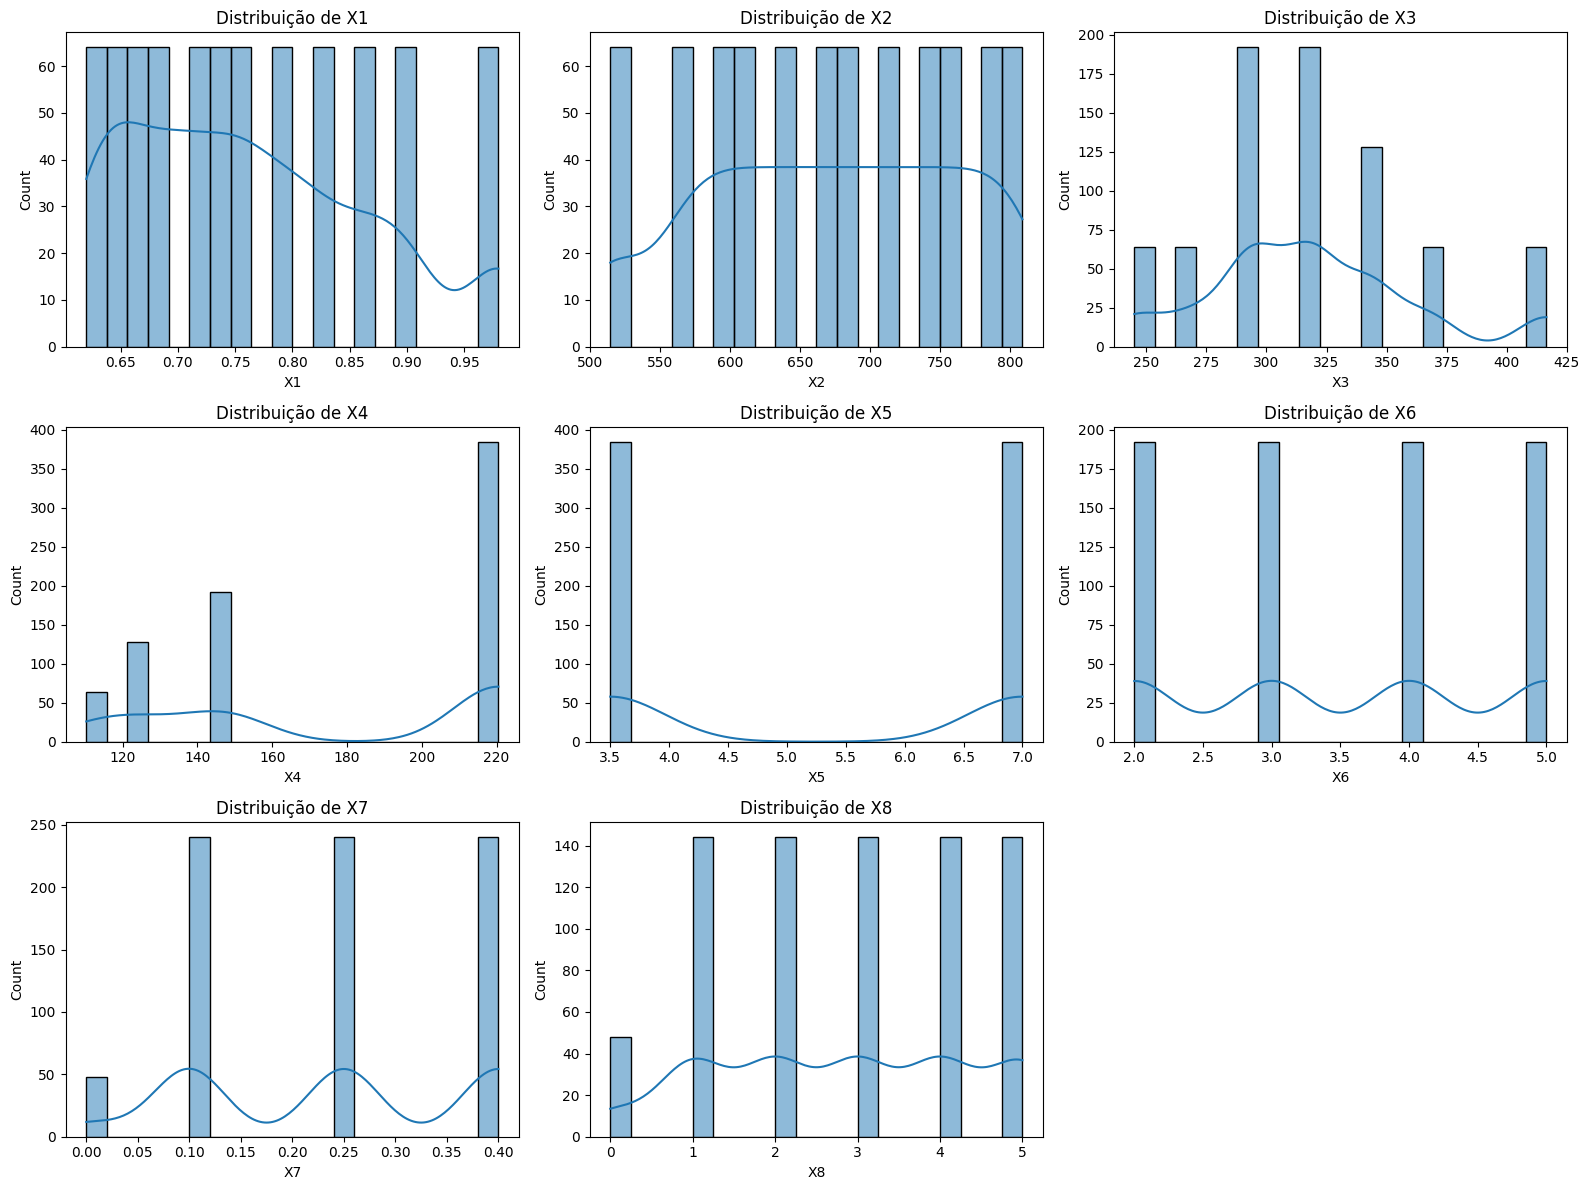

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogramas das variáveis preditoras
X_columns = X.columns

plt.figure(figsize=(16, 12))
for i, col in enumerate(X_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(X[col], kde=True, bins=20)
    plt.title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

#### 1.4 Análise de correlação entre as variáveis

A matriz de correlação de Pearson foi calculada para identificar relações lineares entre as variáveis. Correlações fortes sugerem possíveis relações lineares, enquanto valores próximos de zero indicam ausência de relação. 

In [9]:
import pandas as pd

# Matriz de correlação
df_corr = pd.concat([X, y], axis=1)

corr_matrix = df_corr.corr()

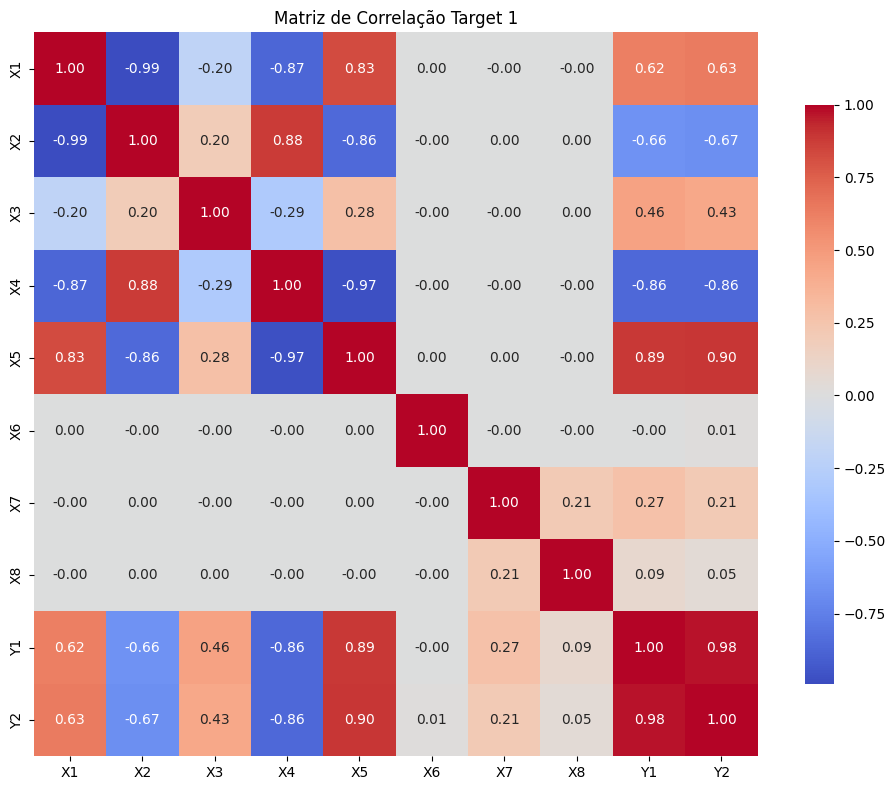

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação Target 1')
plt.tight_layout()
plt.show()

#### 1.6 Relação entre preditores e variáveis-alvo

Nesta etapa, são apresentados gráficos de dispersão (*scatterplots*) entre cada variável preditora e as variáveis-alvo (*Heating Load* e *Cooling Load*). Essa visualização permite explorar possíveis relações não-lineares e padrões específicos que não são capturados pela análise de correlação linear.

Nos gráficos, foi incluída uma linha de tendência linear (*regplot*, em vermelho), que reforça visualmente a direção geral da relação entre as variáveis.

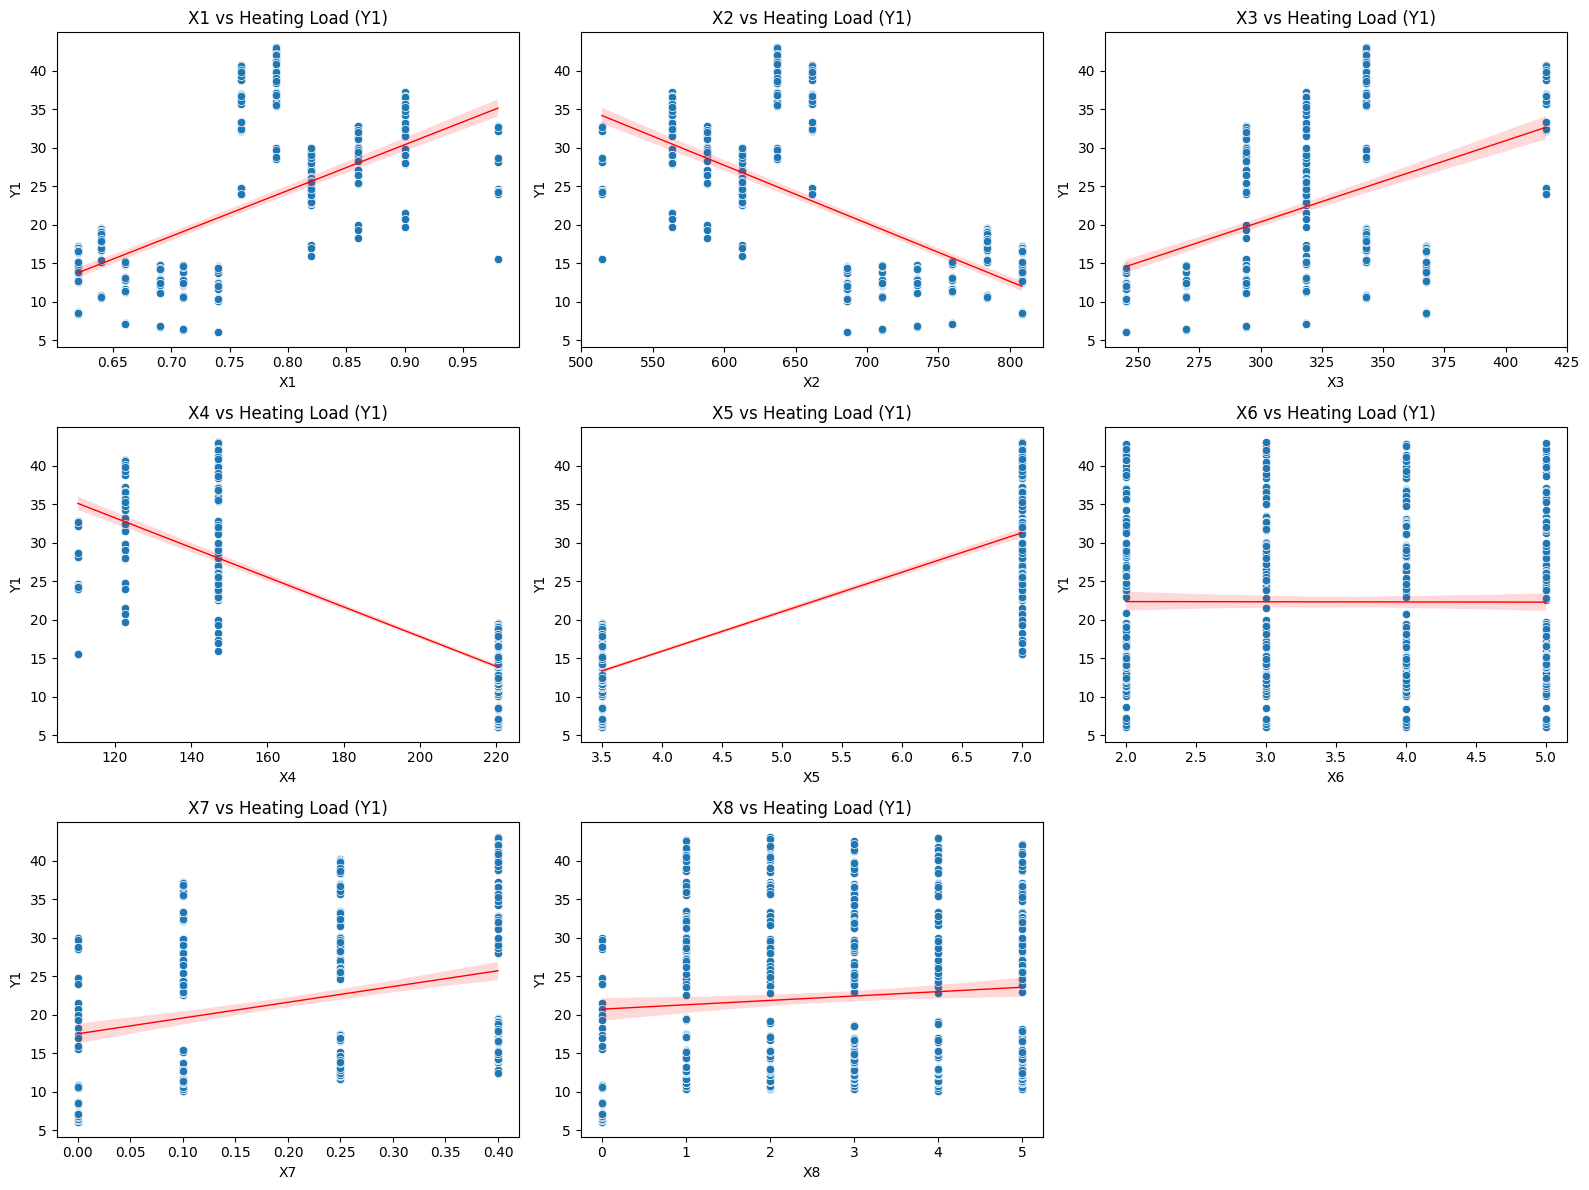

In [11]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(X.columns, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=X[col], y=y['Y1'])
    sns.regplot(x=X[col], y=y['Y1'], scatter=False, color='red', line_kws={"linewidth": 1})
    plt.title(f'{col} vs Heating Load (Y1)')
plt.tight_layout()
plt.show()

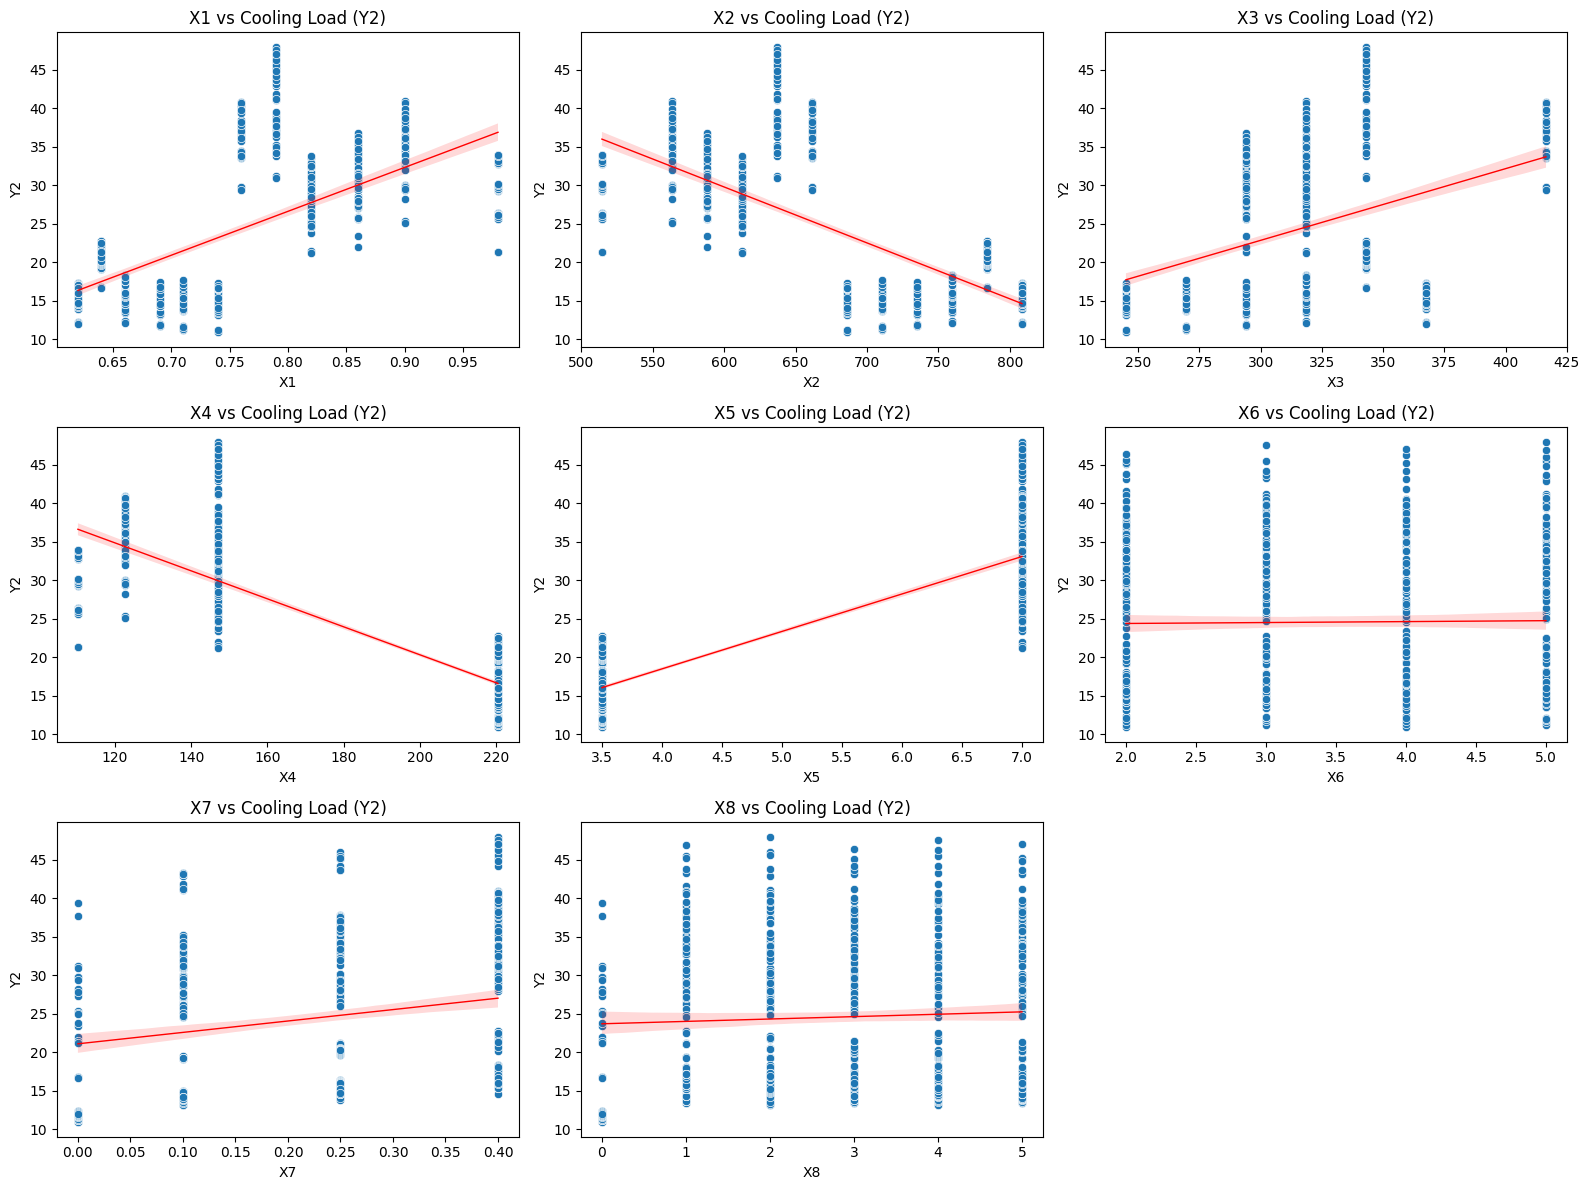

In [12]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(X.columns, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=X[col], y=y['Y2'])
    sns.regplot(x=X[col], y=y['Y2'], scatter=False, color='red', line_kws={"linewidth": 1})
    plt.title(f'{col} vs Cooling Load (Y2)')
plt.tight_layout()
plt.show()

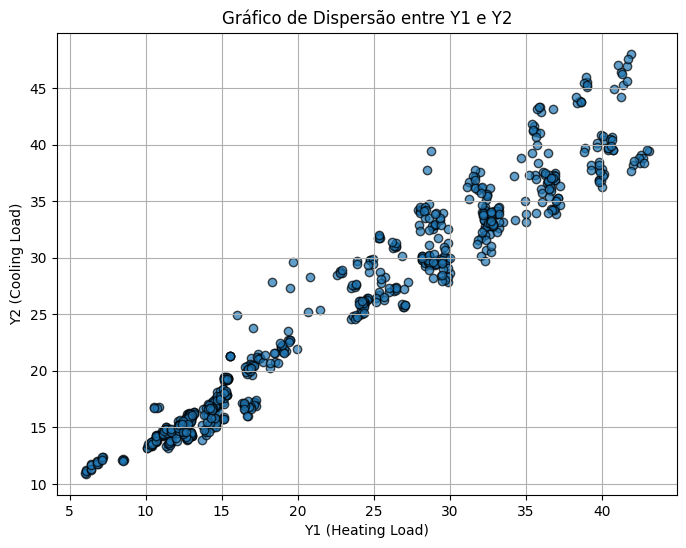

In [13]:
import matplotlib.pyplot as plt

# Criar o gráfico de dispersão usando matplotlib
plt.figure(figsize=(8, 6))
plt.scatter(y['Y1'], y['Y2'], alpha=0.7, edgecolors='k')
plt.title('Gráfico de Dispersão entre Y1 e Y2')
plt.xlabel('Y1 (Heating Load)')
plt.ylabel('Y2 (Cooling Load)')
plt.grid(True)
plt.show()